<a href="https://colab.research.google.com/github/aysh34/cpu-gpu-tpu-ml-benchmark/blob/main/Chartalist_CPU_GPU_Comparison_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chartalist: CPU vs GPU Comparison
## Bitcoin Ransomware Classification — Logistic Regression and SVM

**Dataset:** BitcoinHeist (Ransomware Type Prediction) from [Chartalist](https://chartalist.org)  
**Models:** XGBoost             
**Hardware:** CPU vs GPU  
**Metrics Tracked:** Training Time, RAM Usage, Disk Usage, Accuracy, F1, Precision, Recall

---
**How to use this notebook:**
- Run once with **Runtime > Change runtime type > None (CPU)**
- Run again with **Runtime > Change runtime type > GPU**
- Screenshot the **RAM/Disk bar** (top-right Colab sidebar) after each training cell
- Results are saved to `comparison_results.csv`

XGBoost 3.2.0 | PyTorch 2.10.0+cu128
Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/bitcoin_hw_comparison/comparison_results.csv
✅ GPU DETECTED: Tesla T4  (14.6 GB VRAM)
RAM  : 1.48 / 12.67 GB  (13.9%)
Disk : 42.90 / 112.64 GB  (38.1%)

📸 SCREENSHOT NOW — sidebar baseline [GPU]

Shape: (2916697, 10)
label
white                          2875284
paduaCryptoWall                  12390
montrealCryptoLocker              9315
princetonCerber                   9223
princetonLocky                    6625
montrealCryptXXX                  2419
montrealNoobCrypt                  483
montrealDMALockerv3                354
montrealDMALocker                  251
montrealSamSam                      62
montrealCryptoTorLocker2015         55
montrealGlobeImposter               55
montrealGlobev3                     34
montrealGlobe                       32
montrealWannaCry                    28
montrealRazy                        13
montrealAPT                         11
pa

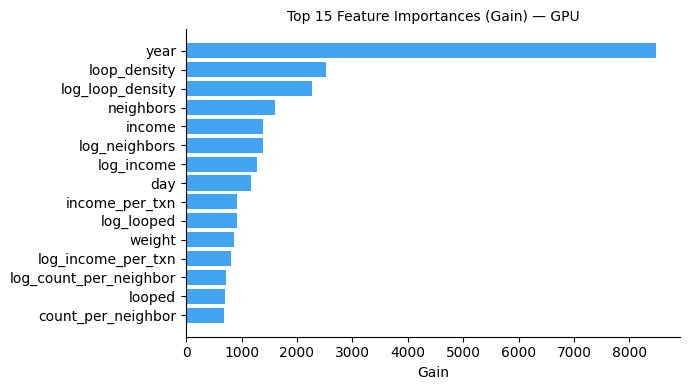

Saved: /content/drive/MyDrive/bitcoin_hw_comparison/feature_importance_GPU.png


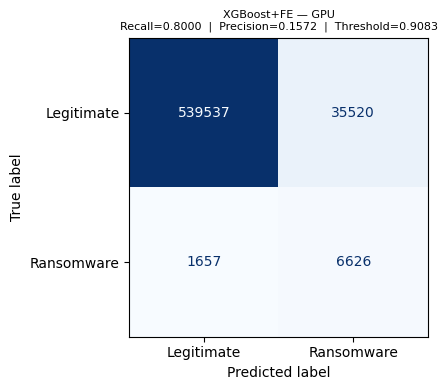

Saved: /content/drive/MyDrive/bitcoin_hw_comparison/confusion_matrix_GPU.png

📸 SCREENSHOT NOW — confusion matrix + sidebar [GPU]

  RESULTS — GPU
     Model  Training Time (s)  RAM Delta (GB)  Accuracy  Ransomware Recall  Ransomware Precision  Threshold  Num Features
XGBoost+FE             7.8729          0.0688    0.9363                0.8                0.1572     0.9083            26

Saved → /content/drive/MyDrive/bitcoin_hw_comparison/comparison_results.csv

📸 SCREENSHOT NOW — results table + sidebar [GPU]


In [1]:
# ── 0. Install dependencies ───────────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "psutil", "pandas", "numpy", "matplotlib",
                       "scikit-learn", "xgboost", "-q"])

# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, time, warnings
import psutil, requests, zipfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import xgboost as xgb

from sklearn.preprocessing   import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve,
)
from collections import Counter

warnings.filterwarnings("ignore")
print(f"XGBoost {xgb.__version__} | PyTorch {torch.__version__}")

# ── 2. Mount Drive first ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/bitcoin_hw_comparison/"
os.makedirs(SAVE_DIR, exist_ok=True)
CSV_PATH = os.path.join(SAVE_DIR, "comparison_results.csv")
print(f"Results will be saved to: {CSV_PATH}")

# ── 3. Detect hardware ────────────────────────────────────────────────────────
def get_hardware_info() -> str:
    if torch.cuda.is_available():
        hardware = "GPU"
        name = torch.cuda.get_device_name(0)
        mem  = torch.cuda.get_device_properties(0).total_memory / 1024 ** 3
        print(f"✅ GPU DETECTED: {name}  ({mem:.1f} GB VRAM)")
    else:
        hardware = "CPU"
        print("✅ CPU MODE — no GPU detected")
    vm   = psutil.virtual_memory()
    disk = psutil.disk_usage("/")
    print(f"RAM  : {vm.used/1024**3:.2f} / {vm.total/1024**3:.2f} GB  ({vm.percent:.1f}%)")
    print(f"Disk : {disk.used/1024**3:.2f} / {disk.total/1024**3:.2f} GB  ({disk.percent:.1f}%)")
    return hardware

HARDWARE = get_hardware_info()
print(f"\n📸 SCREENSHOT NOW — sidebar baseline [{HARDWARE}]")

# ── 4. Load dataset ───────────────────────────────────────────────────────────
print("\nDownloading BitcoinHeist dataset …")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00526/data.zip"
r   = requests.get(url, timeout=120)
with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
    with zf.open("BitcoinHeistData.csv") as f:
        df_raw = pd.read_csv(f)
print(f"Shape: {df_raw.shape}")
print(df_raw["label"].value_counts())

# ── 5. Feature Engineering ────────────────────────────────────────────────────
# BitcoinHeist raw features (8 total):
#   length    — number of transactions in the address lifetime
#   weight    — fraction of input amount passing through
#   count     — number of transactions in a 24h period
#   looped    — fraction of coins sent back to known ransomware addresses
#   neighbors — number of neighbouring addresses
#   income    — total BTC received
#
# Ransomware behaviour signature:
#   - High looped (coins recycled through known addresses)
#   - High count relative to neighbors (rapid repeated small txns)
#   - Low income per transaction (small ransom demands)
#   - Short address lifetime (burner addresses)
#
# Strategy:
#   1. Log-transform all right-skewed features (they span many orders of magnitude)
#   2. Add ratio features that capture the behavioural signature directly
#   3. Use RobustScaler (median/IQR) instead of StandardScaler — more stable
#      with the extreme outliers present in blockchain data

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    fe = df.copy()

    # Safe log1p transform on all base features (handles zeros)
    base = ["length", "weight", "count", "looped", "neighbors", "income"]
    for col in base:
        if col in fe.columns:
            fe[f"log_{col}"] = np.log1p(np.abs(fe[col]))

    eps = 1e-9   # avoid division by zero in all ratios below

    # Ratio: count / neighbors — high = rapid txns through few addresses (ransomware)
    if "count" in fe.columns and "neighbors" in fe.columns:
        fe["count_per_neighbor"] = fe["count"] / (fe["neighbors"] + eps)
        fe["log_count_per_neighbor"] = np.log1p(fe["count_per_neighbor"])

    # Ratio: income / count — low = small individual transactions (ransomware)
    if "income" in fe.columns and "count" in fe.columns:
        fe["income_per_txn"] = fe["income"] / (fe["count"] + eps)
        fe["log_income_per_txn"] = np.log1p(np.abs(fe["income_per_txn"]))

    # Ratio: looped / neighbors — high = coins recycled relative to address spread
    if "looped" in fe.columns and "neighbors" in fe.columns:
        fe["loop_density"] = fe["looped"] / (fe["neighbors"] + eps)
        fe["log_loop_density"] = np.log1p(fe["loop_density"])

    # Ratio: count / length — high = burst activity over short lifetime (ransomware)
    if "count" in fe.columns and "length" in fe.columns:
        fe["count_per_day"] = fe["count"] / (fe["length"] + eps)
        fe["log_count_per_day"] = np.log1p(fe["count_per_day"])

    # Interaction: looped × weight — both high in ransomware recycling patterns
    if "looped" in fe.columns and "weight" in fe.columns:
        fe["loop_weight"] = fe["looped"] * fe["weight"]
        fe["log_loop_weight"] = np.log1p(fe["loop_weight"])

    # Interaction: count × looped — captures high-frequency recycling
    if "count" in fe.columns and "looped" in fe.columns:
        fe["count_loop"] = fe["count"] * fe["looped"]
        fe["log_count_loop"] = np.log1p(fe["count_loop"])

    return fe

# ── 6. Preprocessing ──────────────────────────────────────────────────────────
print("\nPreprocessing + feature engineering …")
df = df_raw.copy()
if "address" in df.columns:
    df.drop(columns=["address"], inplace=True)

# Binary target
le        = LabelEncoder()
y_encoded = le.fit_transform(df["label"])
white_enc = int(le.transform(["white"])[0])
y_binary  = (y_encoded != white_enc).astype(int)

# Apply feature engineering before dropping label
df_feat = engineer_features(df)
feature_cols = [c for c in df_feat.columns if c != "label"]
print(f"Features before engineering : 8")
print(f"Features after  engineering : {len(feature_cols)}")

X = df_feat[feature_cols].values.astype(np.float64)
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)

# RobustScaler: uses median and IQR, not mean/std
# Better than StandardScaler for blockchain data with extreme outliers
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

n_legit        = int((y_train == 0).sum())
n_ransom       = int((y_train == 1).sum())
natural_ratio  = n_legit / n_ransom

print(f"Train : {Counter(y_train)}")
print(f"Test  : {Counter(y_test)}")
print(f"Imbalance ratio (legit/ransom): {natural_ratio:.2f}")

ram  = psutil.virtual_memory().used / 1024 ** 3
disk = psutil.disk_usage("/").used  / 1024 ** 3
print(f"RAM after load : {ram:.2f} GB  |  Disk: {disk:.2f} GB")
print(f"\n📸 SCREENSHOT NOW — sidebar after data load [{HARDWARE}]")

# ── 7. XGBoost training ───────────────────────────────────────────────────────
# Tunable constants — adjust at top level if needed
TARGET_RECALL  = 0.80
SPW_MULTIPLIER = 5     # increase to 7–10 if recall target not met

def train_xgboost(X_tr, y_tr, X_te, y_te, hardware):
    print(f"\n{'='*55}")
    print(f"  XGBoost on {hardware}")
    print(f"{'='*55}")

    if hardware == "GPU" and torch.cuda.is_available():
        extra = {"device": "cuda"}
        print("  Using GPU (device=cuda, tree_method=hist)")
    else:
        extra = {"device": "cpu"}
        print("  Using CPU (device=cpu, tree_method=hist)")

    spw = natural_ratio * SPW_MULTIPLIER
    print(f"  scale_pos_weight : {natural_ratio:.2f} × {SPW_MULTIPLIER} = {spw:.2f}")
    print(f"  Recall target    : ≥ {TARGET_RECALL}")
    print(f"  Features used    : {X_tr.shape[1]}")

    params = {
        "objective":          "binary:logistic",
        "eval_metric":        ["logloss", "aucpr"],
        "tree_method":        "hist",
        "learning_rate":      0.05,
        "max_depth":          8,
        "subsample":          0.8,
        "colsample_bytree":   0.8,
        "min_child_weight":   5,
        "scale_pos_weight":   spw,
        "max_delta_step":     1,
        "gamma":              0.1,
        "seed":               42,
        "nthread":            -1,
        **extra,
    }

    dtrain = xgb.DMatrix(X_tr, label=y_tr,
                         feature_names=[f"f{i}" for i in range(X_tr.shape[1])])
    dtest  = xgb.DMatrix(X_te,
                         feature_names=[f"f{i}" for i in range(X_te.shape[1])])

    ram_b  = psutil.virtual_memory().used / 1024 ** 3
    disk_b = psutil.disk_usage("/").used  / 1024 ** 3
    t0     = time.perf_counter()
    model  = xgb.train(params, dtrain, num_boost_round=400, verbose_eval=False)
    train_time = round(time.perf_counter() - t0, 4)
    ram_a  = psutil.virtual_memory().used / 1024 ** 3
    disk_a = psutil.disk_usage("/").used  / 1024 ** 3

    y_prob = model.predict(dtest)


    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te, y_prob)
    p = prec_arr[:-1]
    r = rec_arr[:-1]
    t = thresh_arr

    valid = np.where(r >= TARGET_RECALL)[0]
    if len(valid) > 0:
        best_idx       = valid[-1]          # highest threshold at target recall
        best_threshold = float(t[best_idx])
        strategy       = f"recall ≥ {TARGET_RECALL} @ best precision"
    else:
        f1_ransom      = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
        best_idx       = int(np.argmax(f1_ransom))
        best_threshold = float(t[best_idx])
        strategy       = "fallback: max ransomware F1 (target recall not achievable)"

    best_threshold = max(best_threshold, 0.05)
    print(f"  Threshold strategy : {strategy}")
    print(f"  Threshold selected : {best_threshold:.4f}")
    print(f"  Precision @ thr    : {p[best_idx]:.4f}  |  Recall: {r[best_idx]:.4f}")

    y_pred             = (y_prob > best_threshold).astype(int)
    class_metrics      = recall_score(y_te, y_pred, average=None)
    ransomware_recall  = float(class_metrics[1])
    ransomware_prec    = float(
        precision_score(y_te, y_pred, average=None, zero_division=0)[1]
    )

    acc  = round(accuracy_score(y_te, y_pred), 4)
    f1w  = round(f1_score(y_te, y_pred, average="weighted"), 4)
    prec = round(precision_score(y_te, y_pred, average="weighted", zero_division=0), 4)
    rec  = round(recall_score(y_te, y_pred,    average="weighted", zero_division=0), 4)

    print(f"\n  Training Time          : {train_time:.4f} s")
    print(f"  RAM Δ                  : {ram_a - ram_b:+.4f} GB")
    print(f"  Disk Δ                 : {disk_a - disk_b:+.6f} GB")
    print(f"  Accuracy               : {acc:.4f}")
    print(f"  F1 (weighted)          : {f1w:.4f}")
    print(f"  Ransomware Recall      : {ransomware_recall:.4f}  ← key metric")
    print(f"  Ransomware Precision   : {ransomware_prec:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=["Legitimate", "Ransomware"]))

    return {
        "Hardware":             hardware,
        "Model":                "XGBoost+FE",
        "Training Time (s)":    train_time,
        "RAM Delta (GB)":       round(ram_a - ram_b,  4),
        "Disk Delta (GB)":      round(disk_a - disk_b, 6),
        "Accuracy":             acc,
        "F1 Score":             f1w,
        "Precision":            prec,
        "Recall":               rec,
        "Ransomware Recall":    round(ransomware_recall, 4),
        "Ransomware Precision": round(ransomware_prec,   4),
        "Threshold":            round(best_threshold, 4),
        "Num Features":         X_tr.shape[1],
        "RAM Before (GB)":      round(ram_b,  3),
        "RAM After (GB)":       round(ram_a,  3),
        "Disk Before (GB)":     round(disk_b, 3),
        "Disk After (GB)":      round(disk_a, 3),
        "xgb_model":            model,
    }

results = train_xgboost(X_train, y_train, X_test, y_test, HARDWARE)

# ── 8. Feature importance (top 15) ───────────────────────────────────────────
model_obj  = results["xgb_model"]
feat_names = [f"f{i}" for i in range(X_train.shape[1])]
col_names  = feature_cols   # original human-readable names

scores = model_obj.get_score(importance_type="gain")
# Map f0, f1 … back to readable names
named_scores = {
    col_names[int(k[1:])]: v
    for k, v in scores.items()
    if int(k[1:]) < len(col_names)
}
top15 = sorted(named_scores.items(), key=lambda x: x[1], reverse=True)[:15]
feat_df = pd.DataFrame(top15, columns=["Feature", "Gain"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(feat_df["Feature"][::-1], feat_df["Gain"][::-1], color="#2196F3", alpha=0.85)
ax.set_xlabel("Gain")
ax.set_title(f"Top 15 Feature Importances (Gain) — {HARDWARE}", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fi_path = os.path.join(SAVE_DIR, f"feature_importance_{HARDWARE}.png")
plt.savefig(fi_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fi_path}")

# ── 9. Confusion matrix ───────────────────────────────────────────────────────
threshold = results["Threshold"]
y_prob_cm = model_obj.predict(xgb.DMatrix(
    X_test, feature_names=[f"f{i}" for i in range(X_test.shape[1])]
))
y_pred_cm = (y_prob_cm > threshold).astype(int)

cm   = confusion_matrix(y_test, y_pred_cm)
disp = ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Ransomware"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"XGBoost+FE — {HARDWARE}\n"
    f"Recall={results['Ransomware Recall']:.4f}  |  "
    f"Precision={results['Ransomware Precision']:.4f}  |  "
    f"Threshold={threshold:.4f}",
    fontsize=8,
)
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_{HARDWARE}.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")
print(f"\n📸 SCREENSHOT NOW — confusion matrix + sidebar [{HARDWARE}]")

# ── 10. Save results ──────────────────────────────────────────────────────────
METRIC_COLS = [
    "Hardware", "Model", "Training Time (s)", "RAM Delta (GB)", "Disk Delta (GB)",
    "Accuracy", "F1 Score", "Precision", "Recall",
    "Ransomware Recall", "Ransomware Precision", "Threshold", "Num Features",
    "RAM Before (GB)", "RAM After (GB)", "Disk Before (GB)", "Disk After (GB)",
]
df_run = pd.DataFrame([{k: results[k] for k in METRIC_COLS}])

print("\n" + "=" * 70)
print(f"  RESULTS — {HARDWARE}")
print("=" * 70)
print(df_run[["Model", "Training Time (s)", "RAM Delta (GB)",
              "Accuracy", "Ransomware Recall",
              "Ransomware Precision", "Threshold",
              "Num Features"]].to_string(index=False))
print("=" * 70)

if os.path.exists(CSV_PATH):
    df_existing = pd.read_csv(CSV_PATH)
    df_combined = pd.concat([df_existing, df_run], ignore_index=True)
    df_combined.drop_duplicates(subset=["Hardware", "Model"], keep="last", inplace=True)
else:
    df_combined = df_run

df_combined.to_csv(CSV_PATH, index=False)
print(f"\nSaved → {CSV_PATH}")
print(f"\n📸 SCREENSHOT NOW — results table + sidebar [{HARDWARE}]")


✅ Both CPU and GPU results found — generating charts …


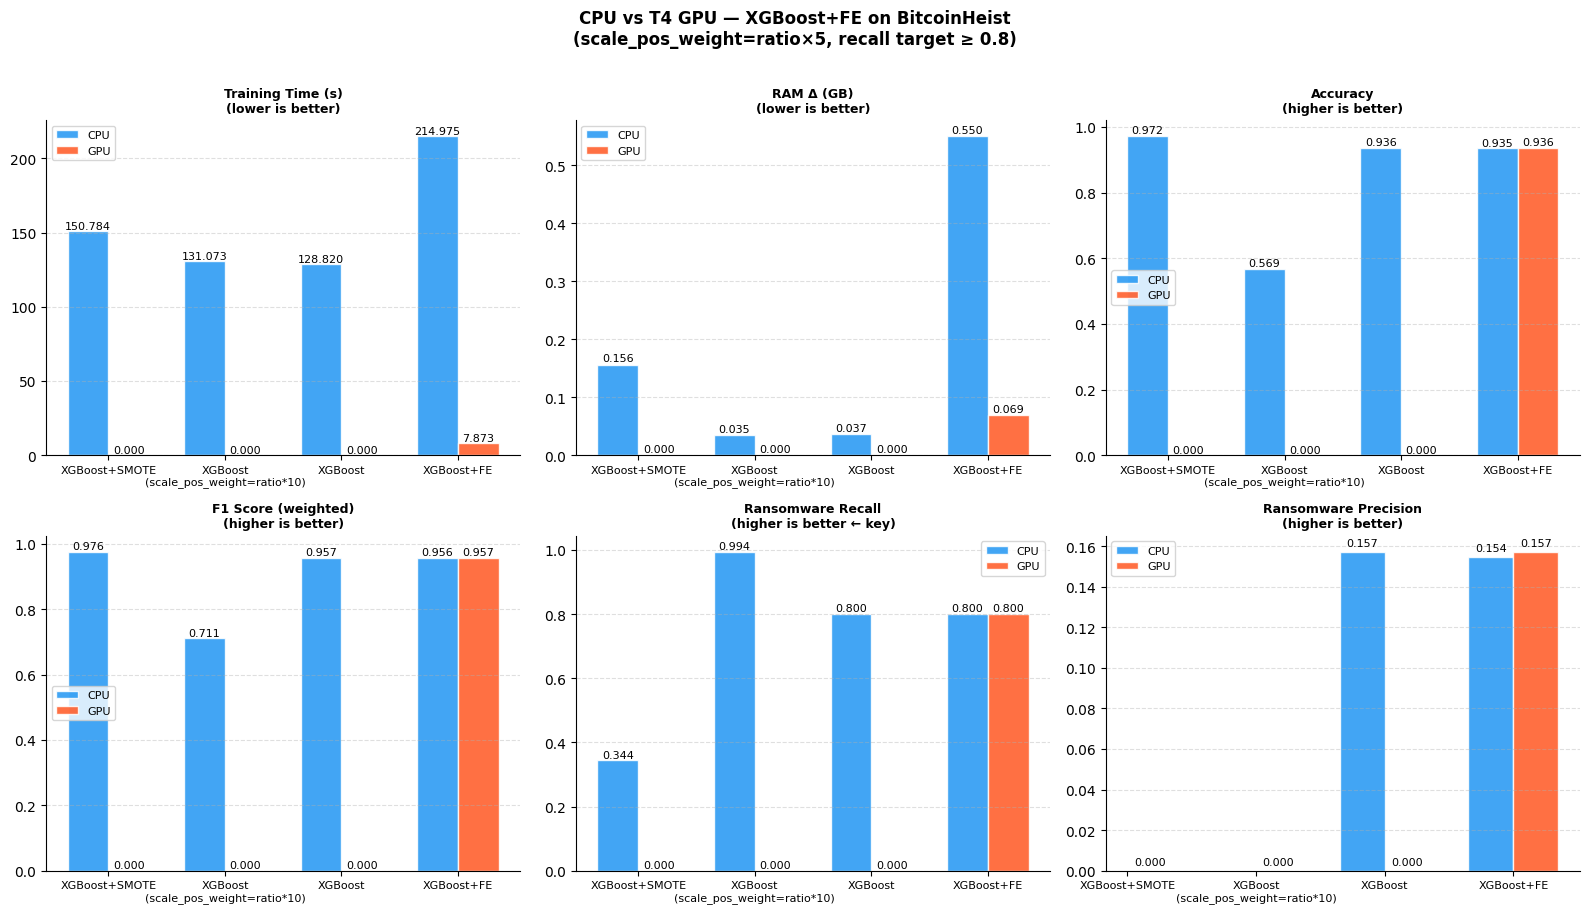

Saved: /content/drive/MyDrive/bitcoin_hw_comparison/bitcoin_cpu_gpu_comparison.png


In [2]:
# ── 11. Comparison charts (auto after both runs) ──────────────────────────────
if not os.path.exists(CSV_PATH):
    print("No results yet — run on CPU and GPU first.")
else:
    df_plot = pd.read_csv(CSV_PATH)
    missing = {"CPU", "GPU"} - set(df_plot["Hardware"].unique())
    if missing:
        print(f"⚠️  Still waiting on: {missing}")
    else:
        print("✅ Both CPU and GPU results found — generating charts …")

        models_list   = df_plot["Model"].unique()
        hardware_list = df_plot["Hardware"].unique()
        colors        = {"CPU": "#2196F3", "GPU": "#FF5722"}

        metrics = [
            ("Training Time (s)",    "Training Time (s)",       "lower is better"),
            ("RAM Delta (GB)",       "RAM Δ (GB)",               "lower is better"),
            ("Accuracy",             "Accuracy",                 "higher is better"),
            ("F1 Score",             "F1 Score (weighted)",      "higher is better"),
            ("Ransomware Recall",    "Ransomware Recall",        "higher is better ← key"),
            ("Ransomware Precision", "Ransomware Precision",     "higher is better"),
        ]

        fig, axes = plt.subplots(2, 3, figsize=(16, 9))
        fig.suptitle(
            f"CPU vs T4 GPU — XGBoost+FE on BitcoinHeist\n"
            f"(scale_pos_weight=ratio×{SPW_MULTIPLIER}, recall target ≥ {TARGET_RECALL})",
            fontsize=12, fontweight="bold", y=1.01,
        )

        for ax, (col, title, note) in zip(axes.flat, metrics):
            x     = np.arange(len(models_list))
            width = 0.35
            for i, hw in enumerate(hardware_list):
                vals = []
                for m in models_list:
                    mask = (df_plot["Hardware"] == hw) & (df_plot["Model"] == m)
                    v    = df_plot.loc[mask, col].values
                    vals.append(float(v[0]) if len(v) > 0 else 0.0)
                bars = ax.bar(x + i * width, vals, width,
                              label=hw, color=colors.get(hw, "#999"),
                              alpha=0.85, edgecolor="white")
                for bar, val in zip(bars, vals):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.002,
                            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
            ax.set_title(f"{title}\n({note})", fontsize=9, fontweight="bold")
            ax.set_xticks(x + width / 2)
            ax.set_xticklabels([m.replace(" (", "\n(") for m in models_list], fontsize=8)
            ax.legend(fontsize=8)
            ax.grid(axis="y", linestyle="--", alpha=0.4)
            ax.spines[["top", "right"]].set_visible(False)

        plt.tight_layout()
        chart_path = os.path.join(SAVE_DIR, "bitcoin_cpu_gpu_comparison.png")
        plt.savefig(chart_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {chart_path}")


In [3]:
# ── Speedup table ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  SPEEDUP vs CPU (Training Time)")
print("=" * 55)
for m in models_list:
    cpu_t = df_plot.loc[(df_plot["Hardware"] == "CPU") &
                        (df_plot["Model"]    == m), "Training Time (s)"].values
    gpu_t = df_plot.loc[(df_plot["Hardware"] == "GPU") &
                        (df_plot["Model"]    == m), "Training Time (s)"].values
    if len(cpu_t) > 0 and len(gpu_t) > 0 and float(gpu_t[0]) > 0:
        speedup = float(cpu_t[0]) / float(gpu_t[0])
        print(f"  {m}: CPU {float(cpu_t[0]):.3f}s  →  "
                f"GPU {float(gpu_t[0]):.3f}s  =  {speedup:.2f}× speedup")
    else:
        print(f"  {m}: missing data for one runtime")

df_plot.to_csv(os.path.join(SAVE_DIR, "speedup_table.csv"), index=False)
print(f"\nFull table saved → {SAVE_DIR}speedup_table.csv")
print("\n📸 FINAL SCREENSHOT — comparison chart + sidebar")

print("\nDone.")


  SPEEDUP vs CPU (Training Time)
  XGBoost+SMOTE: missing data for one runtime
  XGBoost (scale_pos_weight=ratio*10): missing data for one runtime
  XGBoost: missing data for one runtime
  XGBoost+FE: CPU 214.975s  →  GPU 7.873s  =  27.31× speedup

Full table saved → /content/drive/MyDrive/bitcoin_hw_comparison/speedup_table.csv

📸 FINAL SCREENSHOT — comparison chart + sidebar

Done.
